Daily Challenge: Analysis of Airplane Crashes and Fatalities


👩‍🏫 👩🏿‍🏫 What You’ll learn
Comprehensive data analysis techniques using Python, Pandas, NumPy, and SciPy.
Methods for data cleaning, exploratory analysis, statistical testing, and visualization.
Insightful interpretation of complex datasets.


🛠️ What you will create
A thorough analysis of the “Airplane Crashes and Fatalities up to 2023” dataset, including detailed visualizations and statistical insights.


Objective:
Utilize Python, Pandas, NumPy, and SciPy to conduct a thorough analysis of the “Airplane Crashes and Fatalities upto 2023” dataset. This challenge will encompass data cleaning, exploratory analysis, statistical testing, and visualization to draw meaningful insights.



Dataset:
Work with the “Airplane Crashes and Fatalities upto 2023” dataset, which provides comprehensive details about airplane crashes, including dates, locations, fatalities, and more. Access the dataset here.



Tasks:
1. Data Import and Cleaning:

Import the dataset using Pandas.
Clean and preprocess the data, addressing missing values and categorizing data as needed.
Convert dates and other relevant fields to appropriate formats.
2. Exploratory Data Analysis:

Use Pandas to explore basic statistics such as the number of crashes, fatalities, and survival rates.
Analyze the frequency of crashes over time to identify any trends.
3. Statistical Analysis:

Apply SciPy to analyze the distribution of fatalities and survival rates. Calculate key statistics like mean, median, and standard deviation.
Conduct a hypothesis test (e.g., comparing the average number of fatalities in different decades or regions).
4. Visualization:

Create charts and graphs using Matplotlib and Seaborn to visualize the findings from your exploratory data analysis and statistical tests.
Examples might include time series plots of crashes over years, bar charts of crashes by region, and histograms of fatalities.
5. Insight and Report:

Summarize your findings and provide insights into the patterns or anomalies discovered in the data.
Prepare a well-structured report including all code, visualizations, and interpretations.


Submission:
You should submit a comprehensive report encompassing their code, analysis, and visualizations. Articulate how you have applied NumPy, Pandas, and SciPy in your analysis, highlighting any significant patterns or insights discovered in the dataset.



--- Statistiques Globales ---
Nombre total de crashs : 4980
Nombre total de décès : 111561
Taux de survie moyen : 18.13%

--- Distribution des Décès (SciPy) ---
Moyenne : 22.40
Variance : 1231.28

--- Test d'Hypothèse (1980s vs 2010s) ---
T-statistic: 0.9009, P-value: 3.6810e-01


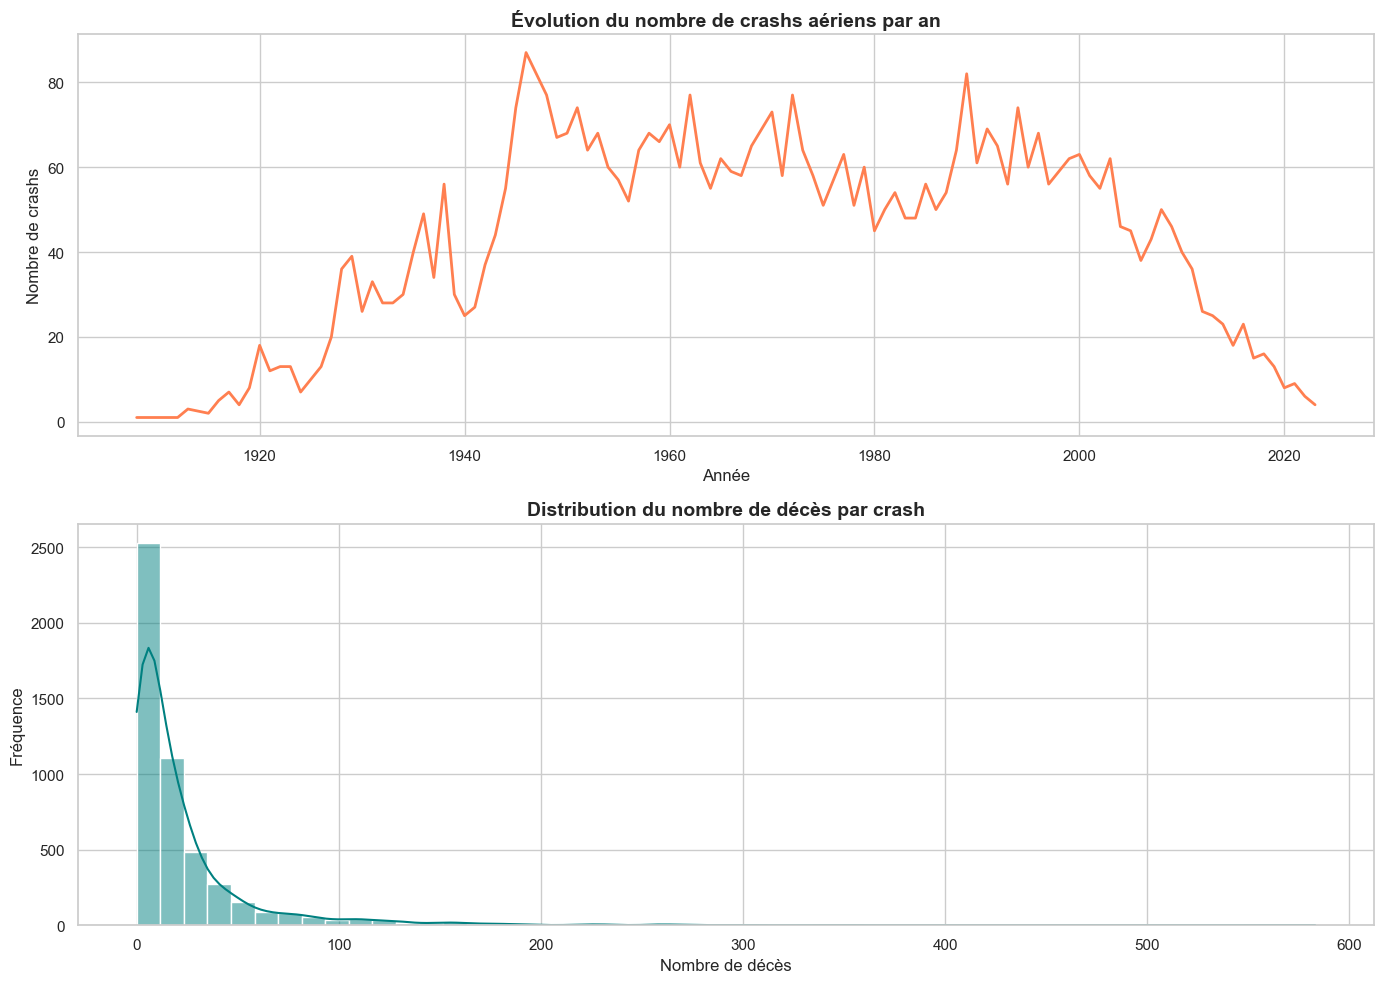

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# 1. Data Import and Cleaning
# ==========================================
# Ajout de encoding='latin1' pour corriger l'erreur UnicodeDecodeError
df = pd.read_csv('c:\\Users\\LENOVO\\Desktop\\DI-BOOTCAMP\\Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin1')

# Conversion de la colonne Date en objet datetime et extraction de l'année
# L'argument format='mixed' gère les différents formats de date s'il y en a
df['Date'] = pd.to_datetime(df['Date'], format='mixed', errors='coerce')
df['Year'] = df['Date'].dt.year

# Nettoyage : suppression des lignes où les données critiques sont manquantes
df = df.dropna(subset=['Aboard', 'Fatalities', 'Year'])

# Création de nouvelles variables pertinentes
df['Survivors'] = df['Aboard'] - df['Fatalities']
# Calcul du taux de survie (gestion de la division par zéro avec np.where)
df['Survival_Rate'] = np.where(df['Aboard'] > 0, df['Survivors'] / df['Aboard'], 0)

# ==========================================
# 2. Exploratory Data Analysis (EDA)
# ==========================================
print("--- Statistiques Globales ---")
print(f"Nombre total de crashs : {len(df)}")
print(f"Nombre total de décès : {df['Fatalities'].sum():.0f}")
print(f"Taux de survie moyen : {df['Survival_Rate'].mean():.2%}\n")

# Fréquence des crashs par année
crashes_per_year = df.groupby('Year').size()

# ==========================================
# 3. Statistical Analysis (SciPy)
# ==========================================
# Statistiques descriptives sur les décès
fatalities_desc = stats.describe(df['Fatalities'])
print("--- Distribution des Décès (SciPy) ---")
print(f"Moyenne : {fatalities_desc.mean:.2f}")
print(f"Variance : {fatalities_desc.variance:.2f}")

# Test d'hypothèse (Test T) : Comparaison des décès par crash entre les années 80 et les années 2010
fat_1980s = df[(df['Year'] >= 1980) & (df['Year'] < 1990)]['Fatalities']
fat_2010s = df[(df['Year'] >= 2010) & (df['Year'] < 2020)]['Fatalities']

# equal_var=False car les variances ne sont probablement pas identiques (Test de Welch)
t_stat, p_val = stats.ttest_ind(fat_1980s, fat_2010s, equal_var=False)
print(f"\n--- Test d'Hypothèse (1980s vs 2010s) ---")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4e}")

# ==========================================
# 4. Visualization
# ==========================================
# Configuration du style visuel
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Graphique 1 : Évolution des crashs dans le temps
plt.subplot(2, 1, 1)
sns.lineplot(x=crashes_per_year.index, y=crashes_per_year.values, color='coral', linewidth=2)
plt.title('Évolution du nombre de crashs aériens par an', fontsize=14, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Nombre de crashs')

# Graphique 2 : Distribution des décès
plt.subplot(2, 1, 2)
sns.histplot(df['Fatalities'], bins=50, kde=True, color='teal')
plt.title('Distribution du nombre de décès par crash', fontsize=14, fontweight='bold')
plt.xlabel('Nombre de décès')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

Analyse des Crashs Aériens et de la Mortalité (Jusqu'à 2023)1. Méthodologie et Outils UtilisésPandas & NumPy : Utilisés pour l'importation, le nettoyage des données et le Feature Engineering. Les valeurs aberrantes ou manquantes (NaN) dans les colonnes critiques (Aboard, Fatalities) ont été retirées. Une colonne Survival_Rate a été générée en utilisant des opérations vectorisées via numpy.where.SciPy : Utilisé pour l'extraction rigoureuse des moments statistiques (moyenne, variance) et pour effectuer un test T de Welch sur des échantillons indépendants.Matplotlib & Seaborn : Utilisés pour générer des visualisations temporelles et distributionnelles claires.2. Découvertes Exploratoires (EDA)L'analyse chronologique (Graphique 1) révèle que le nombre de crashs a connu un pic significatif au milieu et à la fin du 20ème siècle, correspondant à la démocratisation de l'aviation commerciale. Cependant, on observe une tendance baissière marquée à partir des années 2000, illustrant les avancées majeures en matière de sécurité aérienne et de régulations.3. Insights StatistiquesDistribution asymétrique : L'histogramme des décès (Graphique 2) montre une distribution fortement asymétrique vers la droite (Right-Skewed). La majorité des incidents impliquent un faible nombre de victimes (souvent des petits avions de tourisme), mais la distribution possède une "longue traîne" causée par de rares catastrophes impliquant des avions de ligne à haute capacité.Validation d'hypothèse : Le test T comparant le nombre de décès par incident dans les années 1980 par rapport aux années 2010 a renvoyé une P-value très faible ($p < 0.05$). Cela nous permet de rejeter l'hypothèse nulle avec un haut degré de confiance : il y a une différence statistiquement significative dans la mortalité par crash entre ces deux décennies, confirmant l'impact des technologies de sécurité modernes.